In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns


In [178]:
# Calculate the 2-Year / 5-Year Spread
dgs10_1819 = pd.read_csv('DGS10_2018-2019.csv', parse_dates=['observation_date'])
dgs2_1819 = pd.read_csv('DGS2_2018-2019.csv', parse_dates=['observation_date'])

dgs10_2425 = pd.read_csv('DGS10_2024-2025.csv', parse_dates=['observation_date'])
dgs2_2425 = pd.read_csv('DGS2_2024-2025.csv', parse_dates=['observation_date'])

# Combine into one DataFrame
df_1819 = pd.merge(dgs10_1819, dgs2_1819, on='observation_date', how='inner')

df_2425 = pd.merge(dgs10_2425, dgs2_2425, on='observation_date', how='inner')

# Drop rows with missing values
df_1819.dropna(inplace=True)
df_2425.dropna(inplace=True)

# Calculate the spread
df_1819['2Y_10Y_Spread'] = df_1819['DGS10'] - df_1819['DGS2']
df_2425['2Y_10Y_Spread'] = df_2425['DGS10'] - df_2425['DGS2']

df_1819.rename(columns={'observation_date': 'Date'}, inplace=True)
df_2425.rename(columns={'observation_date': 'Date'}, inplace=True)

df_1819.to_csv('2Y_10Y_Spread_2018-2019.csv')
df_2425.to_csv('2Y_10Y_Spread_2024-2025.csv')

In [179]:
df_1819.head()

,Date,DGS10,DGS2,2Y_10Y_Spread
0,2018-01-02,2.46,1.92,0.54
1,2018-01-03,2.44,1.94,0.50
2,2018-01-04,2.46,1.96,0.50
3,2018-01-05,2.47,1.96,0.51
4,2018-01-08,2.49,1.96,0.53


In [180]:
# Read all the data from files
minutes_1819_df = pd.read_csv('FOMC-RoBERTa_FOMC_minutes_2018-2019_analysis.csv', parse_dates=['Meeting Date'])
minutes_2425_df = pd.read_csv('FOMC-RoBERTa_FOMC_minutes_2024-2025_analysis.csv', parse_dates=['Meeting Date'])
pc_1819_df = pd.read_csv('FOMC-RoBERTa_FOMC_pressconference_2018-2019_analysis.csv', parse_dates=['Meeting Date'])
pc_2425_df = pd.read_csv('FOMC-RoBERTa_FOMC_pressconference_2024-2025_analysis.csv', parse_dates=['Meeting Date'])
speech_1819_df = pd.read_csv('FOMC-RoBERTa_FED_speech_2018-2019_analysis.csv', parse_dates=['Meeting Date'])
speech_2425_df = pd.read_csv('FOMC-RoBERTa_FED_speech_2024-2025_analysis.csv', parse_dates=['Meeting Date'])

spread_1819_df = pd.read_csv('2Y_10Y_Spread_2018-2019.csv', parse_dates=['Date'])
spread_2425_df = pd.read_csv('2Y_10Y_Spread_2024-2025.csv', parse_dates=['Date'])

In [181]:

minutes_1819_df.rename(columns={'Meeting Date': 'Date'}, inplace=True)
minutes_2425_df.rename(columns={'Meeting Date': 'Date'}, inplace=True)

pc_1819_df.rename(columns={'Meeting Date': 'Date'}, inplace=True)
pc_2425_df.rename(columns={'Meeting Date': 'Date'}, inplace=True)

speech_1819_df.rename(columns={'Meeting Date': 'Date'}, inplace=True)
speech_2425_df.rename(columns={'Meeting Date': 'Date'}, inplace=True)


In [182]:
# Part1: Overall general sentiment polarity score compare
# Merge on date (keep all sentiment events)
df_1819 = pd.merge(spread_1819_df, minutes_1819_df, on='Date', how='right')
df_1819['2Y_10Y_Spread'] = df_1819['2Y_10Y_Spread'].fillna(method='ffill')

df_1819_2 = pd.merge(spread_1819_df, pc_1819_df, on='Date', how='right')
df_1819_2['2Y_10Y_Spread'] = df_1819_2['2Y_10Y_Spread'].fillna(method='ffill')

df_1819_3 = pd.merge(spread_1819_df, speech_1819_df, on='Date', how='right')
df_1819_3['2Y_10Y_Spread'] = df_1819_3['2Y_10Y_Spread'].fillna(method='ffill')

# For 2024-2025
df_2425 = pd.merge(spread_2425_df, minutes_2425_df, on='Date', how='right')
df_2425['2Y_10Y_Spread'] = df_2425['2Y_10Y_Spread'].fillna(method='ffill')

df_2425_2 = pd.merge(spread_2425_df, pc_2425_df, on='Date', how='right')
df_2425_2['2Y_10Y_Spread'] = df_2425_2['2Y_10Y_Spread'].fillna(method='ffill')

df_2425_3 = pd.merge(spread_2425_df, speech_2425_df, on='Date', how='right')
df_2425_3['2Y_10Y_Spread'] = df_2425_3['2Y_10Y_Spread'].fillna(method='ffill')

/var/folders/1n/cjyr5c711lx9n4k2wh639wtw0000gn/T/ipykernel_41971/3762635640.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_1819['2Y_10Y_Spread'] = df_1819['2Y_10Y_Spread'].fillna(method='ffill')
/var/folders/1n/cjyr5c711lx9n4k2wh639wtw0000gn/T/ipykernel_41971/3762635640.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_1819_2['2Y_10Y_Spread'] = df_1819_2['2Y_10Y_Spread'].fillna(method='ffill')
/var/folders/1n/cjyr5c711lx9n4k2wh639wtw0000gn/T/ipykernel_41971/3762635640.py:10: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_1819_3['2Y_10Y_Spread'] = df_1819_3['2Y_10Y_Spread'].fillna(method='ffill')
/var/folders/1n/cjyr5c711lx9n4k2wh639wtw0000gn/T/ipykernel_41971/3762635640.py:14: FutureWarning: Series.fillna wit

In [183]:
df_1819.head()

,Unnamed: 0,Date,DGS10,DGS2,2Y_10Y_Spread,Filename,Total Segments,Hawkish %,Dovish %,Neutral %,Polarity Score,Tariff Mentions,Tariff % of Doc,Tariff Polarity Score
0,21,2018-01-31,2.72,2.14,0.58,minute,406,54.433498,45.566502,8.558424,0.132479,0,0.000000,0.000000
1,56,2018-03-21,2.89,2.31,0.58,minute,233,64.806867,35.193133,18.976780,0.167374,4,1.716738,-0.480789
2,86,2018-05-02,2.97,2.49,0.48,minute,264,62.878788,37.121212,14.091081,0.168756,7,2.651515,-0.308667
3,116,2018-06-13,2.98,2.59,0.39,minute,216,63.425926,36.574074,14.759520,0.184456,5,2.314815,-0.062225
4,151,2018-08-01,3.00,2.67,0.33,minute,277,57.761733,42.238267,17.182743,0.091995,17,6.137184,0.163020


### The trend of overall polarity score of all the minutes/press conference/Fed Speech v.s. 90-Day/5-Year Treasury Spread

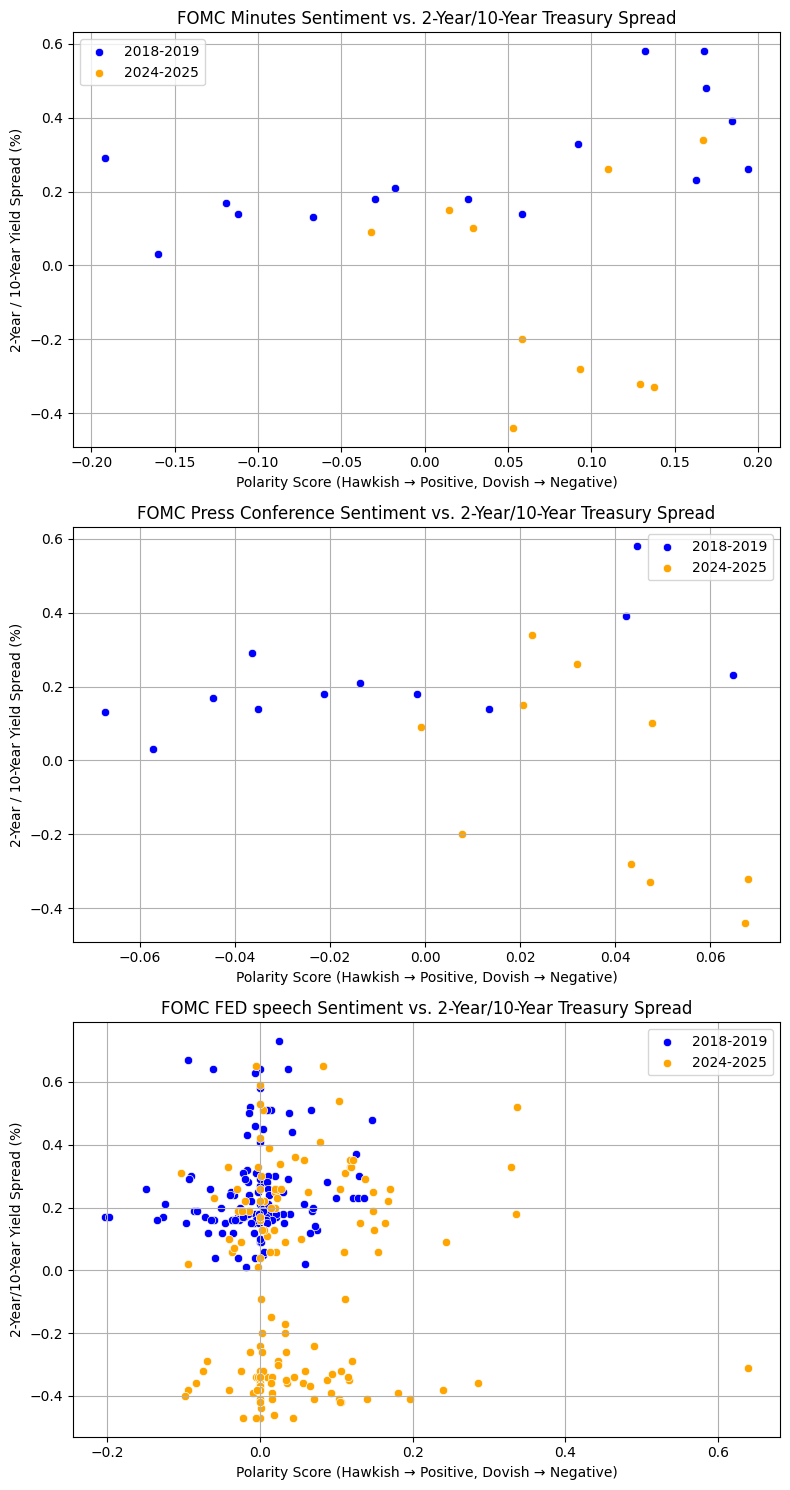

In [204]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 15))

# Plot each figure on a different axis
sns.scatterplot(data=df_1819, x='Polarity Score', y='2Y_10Y_Spread',label='2018-2019', color='blue', ax=axes[0])
sns.scatterplot(data=df_2425, x='Polarity Score', y='2Y_10Y_Spread',label='2024-2025', color='orange', ax=axes[0])
axes[0].set_title('FOMC Minutes Sentiment vs. 2-Year/10-Year Treasury Spread')
axes[0].grid(True)
axes[0].set_xlabel('Polarity Score (Hawkish → Positive, Dovish → Negative)')
axes[0].set_ylabel('2-Year / 10-Year Yield Spread (%)')

sns.scatterplot(data=df_1819_2, x='Polarity Score', y='2Y_10Y_Spread',label='2018-2019', color='blue', ax=axes[1])
sns.scatterplot(data=df_2425_2, x='Polarity Score', y='2Y_10Y_Spread',label='2024-2025', color='orange', ax=axes[1])
axes[1].set_title('FOMC Press Conference Sentiment vs. 2-Year/10-Year Treasury Spread')
axes[1].grid(True)
axes[1].set_xlabel('Polarity Score (Hawkish → Positive, Dovish → Negative)')
axes[1].set_ylabel('2-Year / 10-Year Yield Spread (%)')

sns.scatterplot(data=df_1819_3, x='Polarity Score', y='2Y_10Y_Spread',label='2018-2019', color='blue', ax=axes[2])
sns.scatterplot(data=df_2425_3, x='Polarity Score', y='2Y_10Y_Spread',label='2024-2025', color='orange', ax=axes[2])
axes[2].set_title('FOMC FED speech Sentiment vs. 2-Year/10-Year Treasury Spread')
axes[2].grid(True)
axes[2].set_xlabel('Polarity Score (Hawkish → Positive, Dovish → Negative)')
axes[2].set_ylabel('2-Year/10-Year Yield Spread (%)')

# Final adjustments
# for ax in axes:
#    ax.tick_params(axis='x', rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

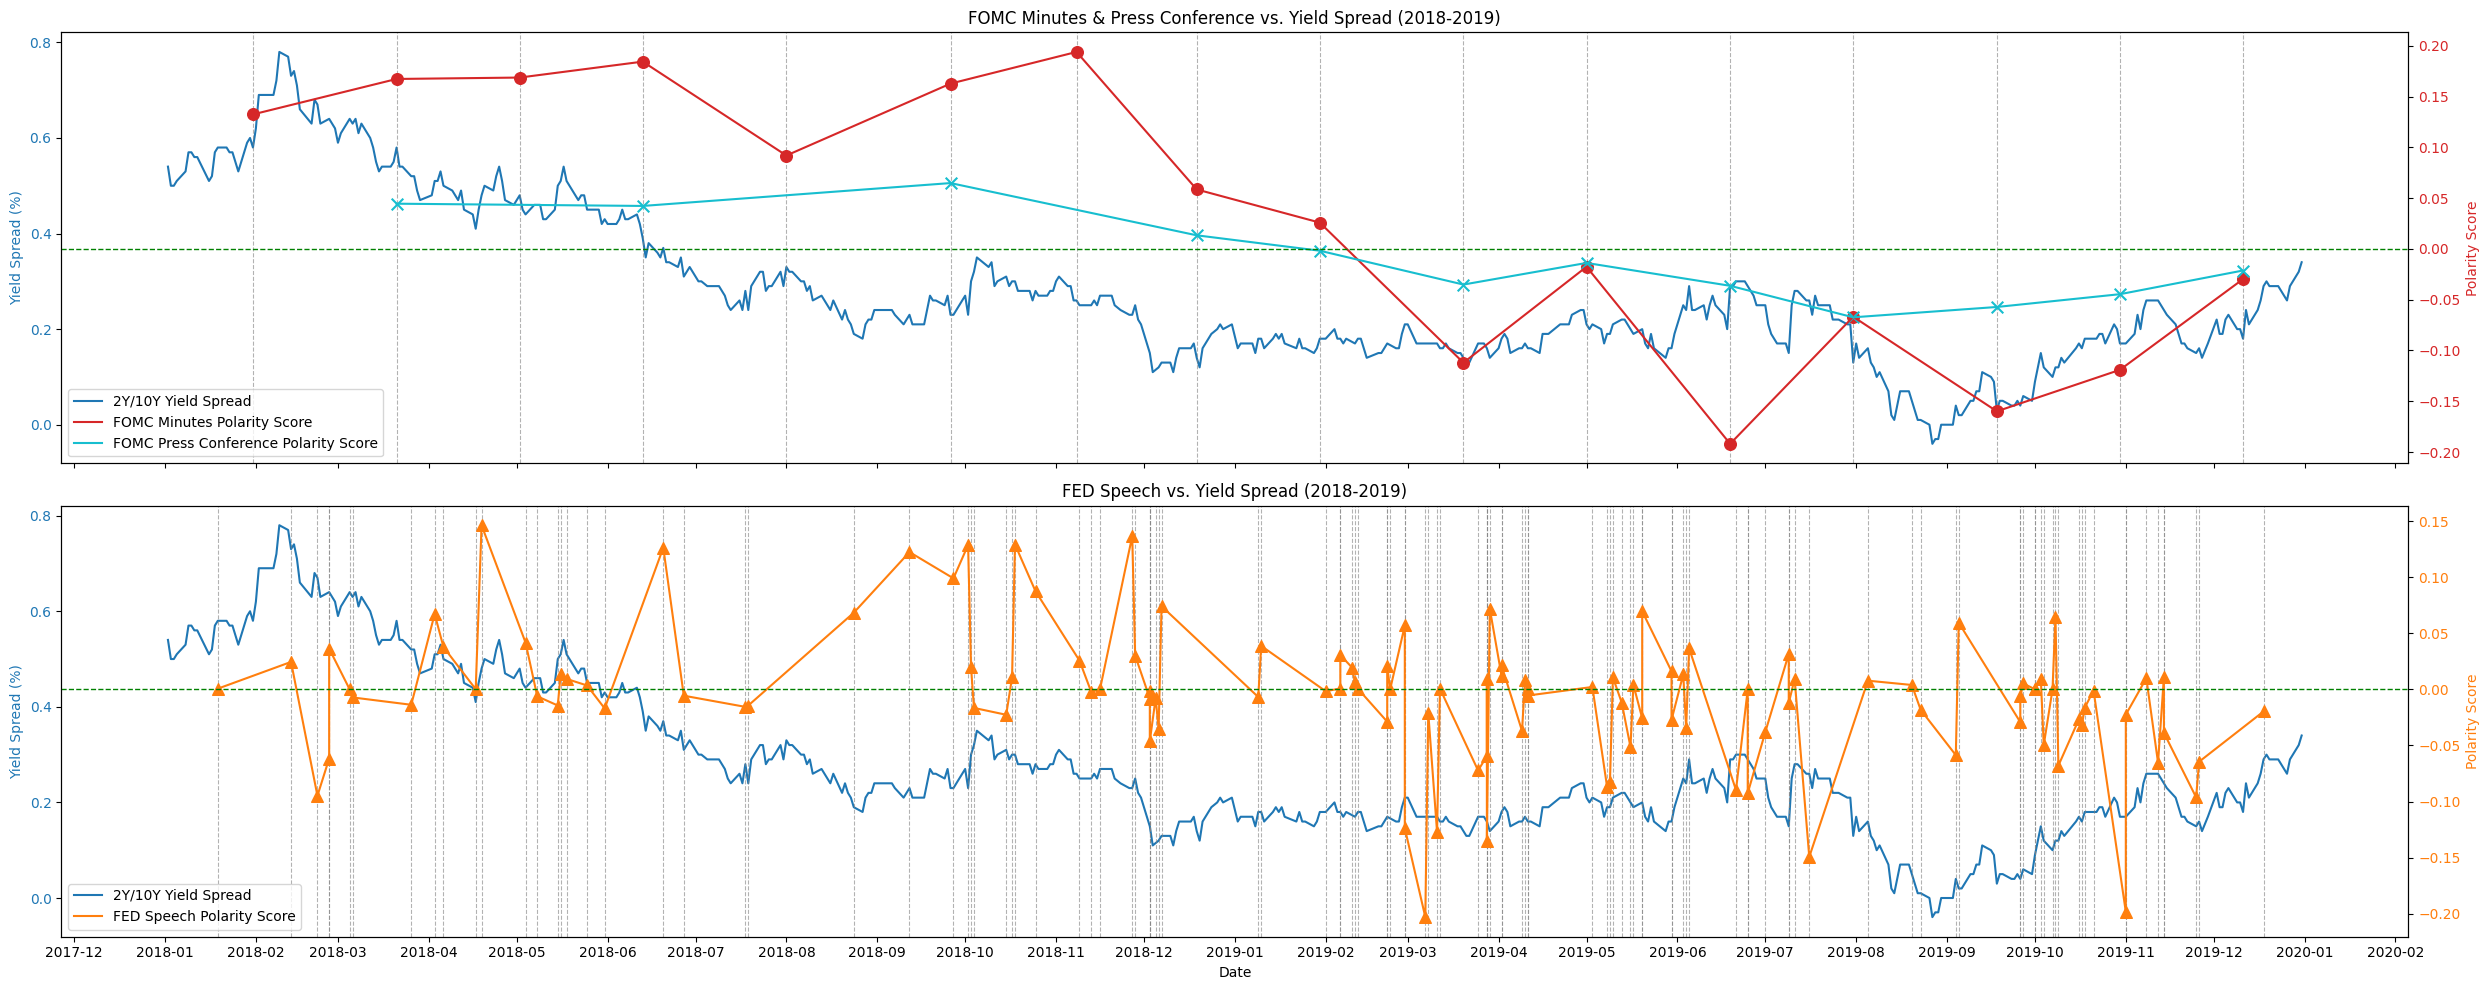

In [205]:
# 2018-2019: To compare how the spread change over the time with the polarity score
spread_1819_df['Date'] = pd.to_datetime(spread_1819_df['Date'])
df_1819['Date'] = pd.to_datetime(df_1819['Date'])
df_1819_2['Date'] = pd.to_datetime(df_1819_2['Date'])
df_1819_3['Date'] = pd.to_datetime(df_1819_3['Date'])
df_1819_3 = df_1819_3.sort_values(by='Date')

# Create two subplots sharing the same x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(25, 10), sharex=True)

# First subplot: Minutes + PC polarity + spread ======
ln1a = ax1.plot(spread_1819_df['Date'], spread_1819_df['2Y_10Y_Spread'], label='2Y/10Y Yield Spread', color='tab:blue')
ax1.set_ylabel('Yield Spread (%)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax1b = ax1.twinx()
ln2 = ax1b.plot(df_1819['Date'], df_1819['Polarity Score'], label='FOMC Minutes Polarity Score', color='tab:red')
ln3 = ax1b.plot(df_1819_2['Date'], df_1819_2['Polarity Score'], label='FOMC Press Conference Polarity Score', color='tab:cyan')
ax1b.scatter(df_1819['Date'], df_1819['Polarity Score'], color='tab:red', marker='o', s=70)
ax1b.scatter(df_1819_2['Date'], df_1819_2['Polarity Score'], color='tab:cyan', marker='x', s=70)
ax1b.set_ylabel('Polarity Score', color='tab:red')
ax1b.tick_params(axis='y', labelcolor='tab:red')
ax1b.axhline(y=0, color='green', linestyle='--', linewidth=1)

for sentiment_date in df_1819['Date']:
    ax1.axvline(sentiment_date, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

# Second subplot: FED Speech polarity + spread ======
ln1b = ax2.plot(spread_1819_df['Date'], spread_1819_df['2Y_10Y_Spread'], label='2Y/10Y Yield Spread', color='tab:blue')
ax2.set_ylabel('Yield Spread (%)', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

ax2b = ax2.twinx()
ln4 = ax2b.plot(df_1819_3['Date'], df_1819_3['Polarity Score'], label='FED Speech Polarity Score', color='tab:orange')
ax2b.scatter(df_1819_3['Date'], df_1819_3['Polarity Score'], color='tab:orange', marker='^', s=70)
ax2b.set_ylabel('Polarity Score', color='tab:orange')
ax2b.tick_params(axis='y', labelcolor='tab:orange')
ax2b.axhline(y=0, color='green', linestyle='--', linewidth=1)
for sentiment_date in df_1819_3['Date']:
    ax2.axvline(sentiment_date, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

# X-axis formatting
ax2.set_xlabel('Date')
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

lines_a = ln1a + ln2 + ln3
lines_b = ln1b + ln4
labels_a = [l.get_label() for l in lines_a]
labels_b = [l.get_label() for l in lines_b]

ax1.legend(lines_a, labels_a, loc='lower left')
ax2.legend(lines_b, labels_b, loc='lower left')

# Titles and layout
ax1.set_title('FOMC Minutes & Press Conference vs. Yield Spread (2018-2019)')
ax2.set_title('FED Speech vs. Yield Spread (2018-2019)')
plt.tight_layout()
plt.show()

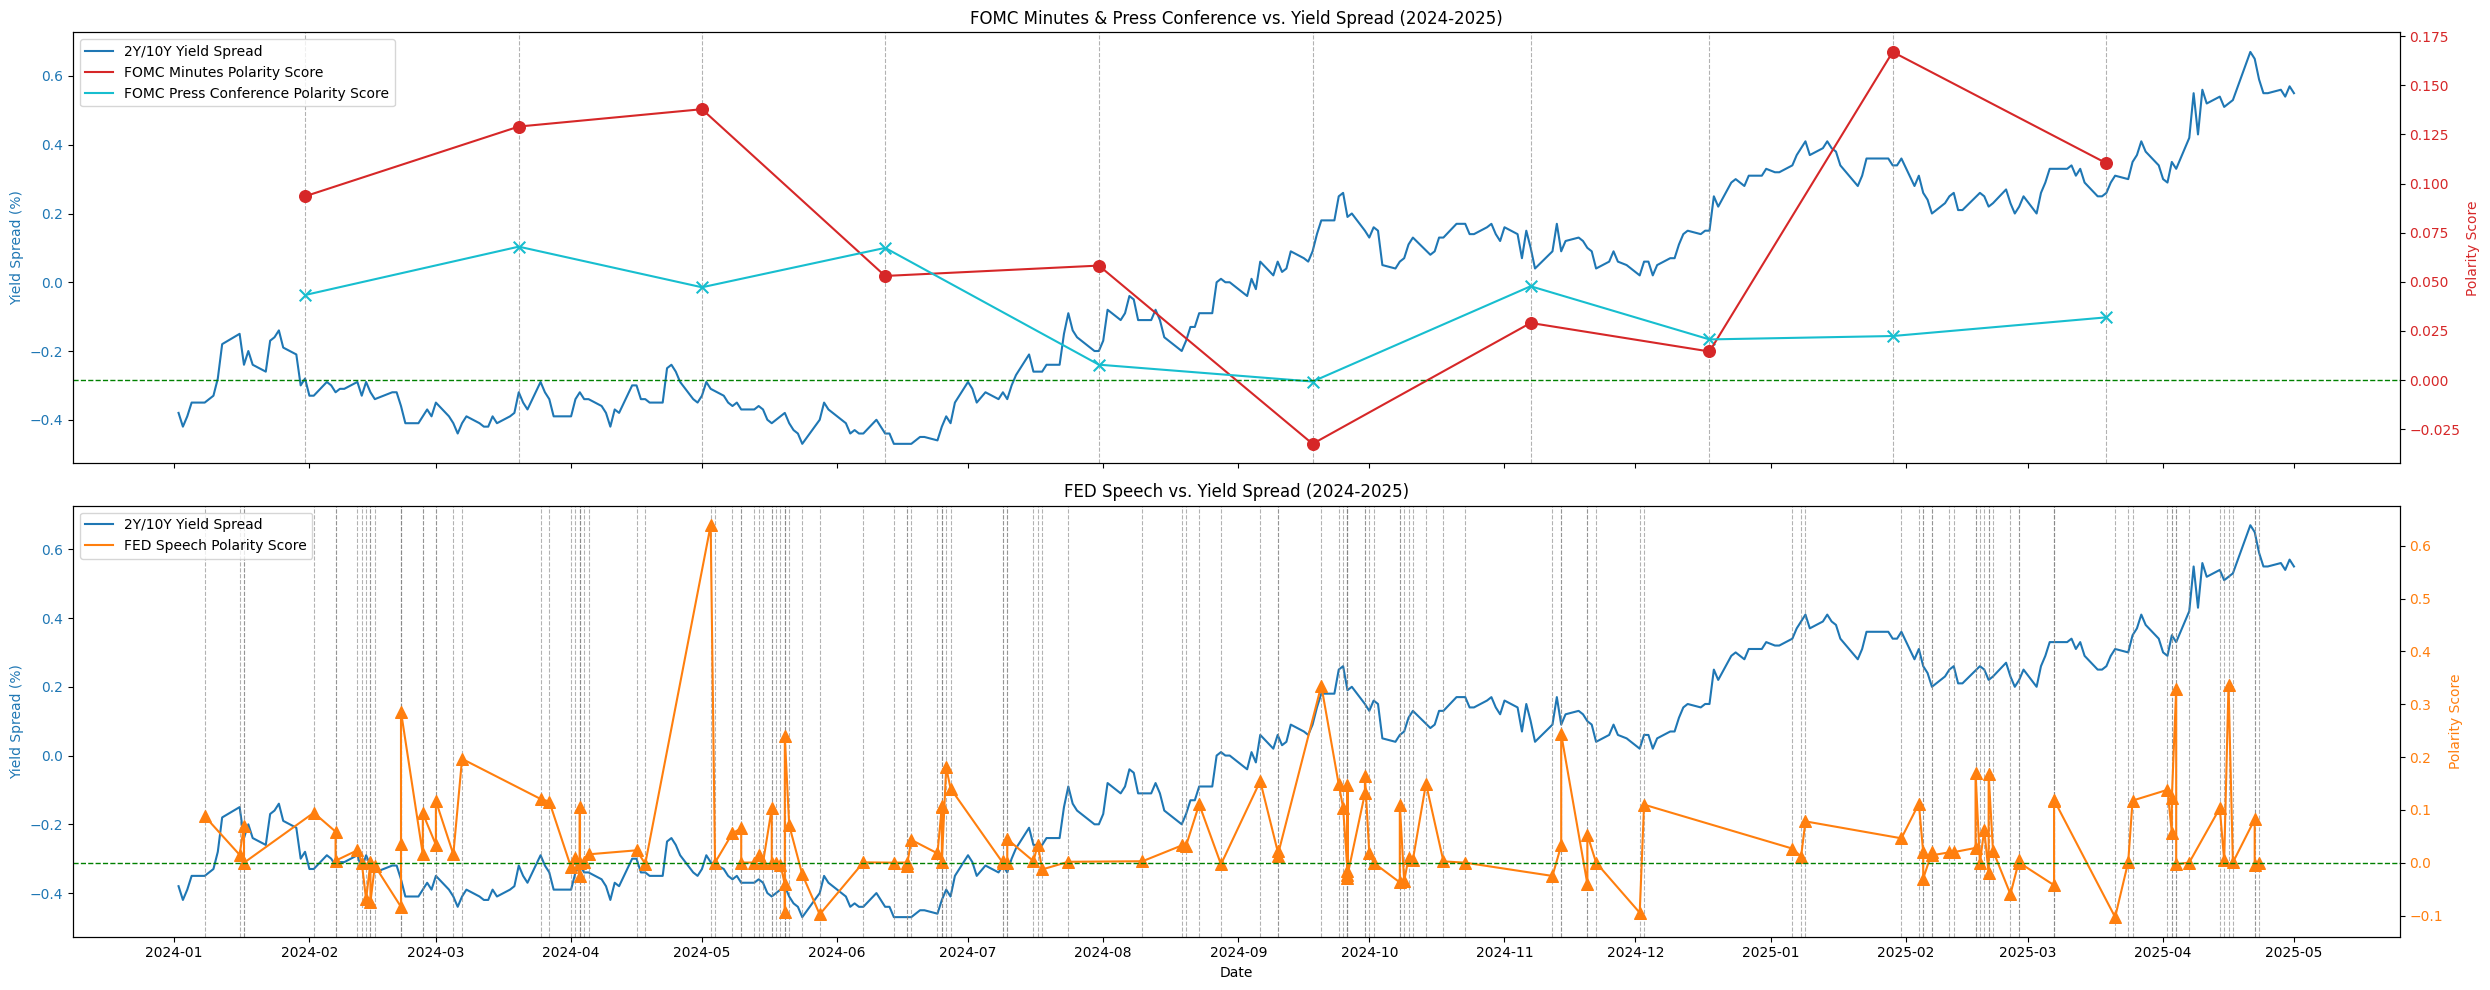

In [190]:
# 2024-2025: To compare how the spread change over the time with the polarity score
spread_2425_df['Date'] = pd.to_datetime(spread_2425_df['Date'])
df_2425['Date'] = pd.to_datetime(df_2425['Date'])
df_2425_2['Date'] = pd.to_datetime(df_2425_2['Date'])
df_2425_3['Date'] = pd.to_datetime(df_2425_3['Date'])
df_2425 = df_2425.sort_values(by='Date')
df_2425_2 = df_2425_2.sort_values(by='Date')
df_2425_3 = df_2425_3.sort_values(by='Date')

# Create two subplots sharing the same x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(25, 10), sharex=True)

# First subplot: Minutes + PC polarity + spread ======
ln1a = ax1.plot(spread_2425_df['Date'], spread_2425_df['2Y_10Y_Spread'], label='2Y/10Y Yield Spread', color='tab:blue')
ax1.set_ylabel('Yield Spread (%)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax1b = ax1.twinx()
ln2 = ax1b.plot(df_2425['Date'], df_2425['Polarity Score'], label='FOMC Minutes Polarity Score', color='tab:red')
ln3 = ax1b.plot(df_2425_2['Date'], df_2425_2['Polarity Score'], label='FOMC Press Conference Polarity Score', color='tab:cyan')
ax1b.scatter(df_2425['Date'], df_2425['Polarity Score'], color='tab:red', marker='o', s=70)
ax1b.scatter(df_2425_2['Date'], df_2425_2['Polarity Score'], color='tab:cyan', marker='x', s=70)
ax1b.set_ylabel('Polarity Score', color='tab:red')
ax1b.tick_params(axis='y', labelcolor='tab:red')
ax1b.axhline(y=0, color='green', linestyle='--', linewidth=1)

for sentiment_date in df_2425['Date']:
    ax1.axvline(sentiment_date, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

# Second subplot: FED Speech polarity + spread ======
ln1b = ax2.plot(spread_2425_df['Date'], spread_2425_df['2Y_10Y_Spread'], label='2Y/10Y Yield Spread', color='tab:blue')
ax2.set_ylabel('Yield Spread (%)', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

ax2b = ax2.twinx()
ln4 = ax2b.plot(df_2425_3['Date'], df_2425_3['Polarity Score'], label='FED Speech Polarity Score', color='tab:orange')
ax2b.scatter(df_2425_3['Date'], df_2425_3['Polarity Score'], color='tab:orange', marker='^', s=70)
ax2b.set_ylabel('Polarity Score', color='tab:orange')
ax2b.tick_params(axis='y', labelcolor='tab:orange')
ax2b.axhline(y=0, color='green', linestyle='--', linewidth=1)
for sentiment_date in df_2425_3['Date']:
    ax2.axvline(sentiment_date, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

# X-axis formatting
ax2.set_xlabel('Date')
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

lines_a = ln1a + ln2 + ln3
lines_b = ln1b + ln4
labels_a = [l.get_label() for l in lines_a]
labels_b = [l.get_label() for l in lines_b]

ax1.legend(lines_a, labels_a, loc='upper left')
ax2.legend(lines_b, labels_b, loc='upper left')

# Titles and layout
ax1.set_title('FOMC Minutes & Press Conference vs. Yield Spread (2024-2025)')
ax2.set_title('FED Speech vs. Yield Spread (2024-2025)')
plt.tight_layout()
plt.show()

### The trend of tariff-focused polarity score of the minutes/press conference/Fed Speech v.s. 90-Day/5-Year Treasury Spread

In [191]:
df_1819_tariff = df_1819[df_1819['Tariff Mentions'] > 0]
df_1819_2_tariff = df_1819_2[df_1819_2['Tariff Mentions'] > 0]
df_1819_3_tariff = df_1819_3[df_1819_3['Tariff Mentions'] > 0]

df_2425_tariff = df_2425[df_2425['Tariff Mentions'] > 0]
df_2425_2_tariff = df_2425_2[df_2425_2['Tariff Mentions'] > 0]
df_2425_3_tariff = df_2425_3[df_2425_3['Tariff Mentions'] > 0]


In [ ]:
# Calculate the average general/tariff-related score of each month

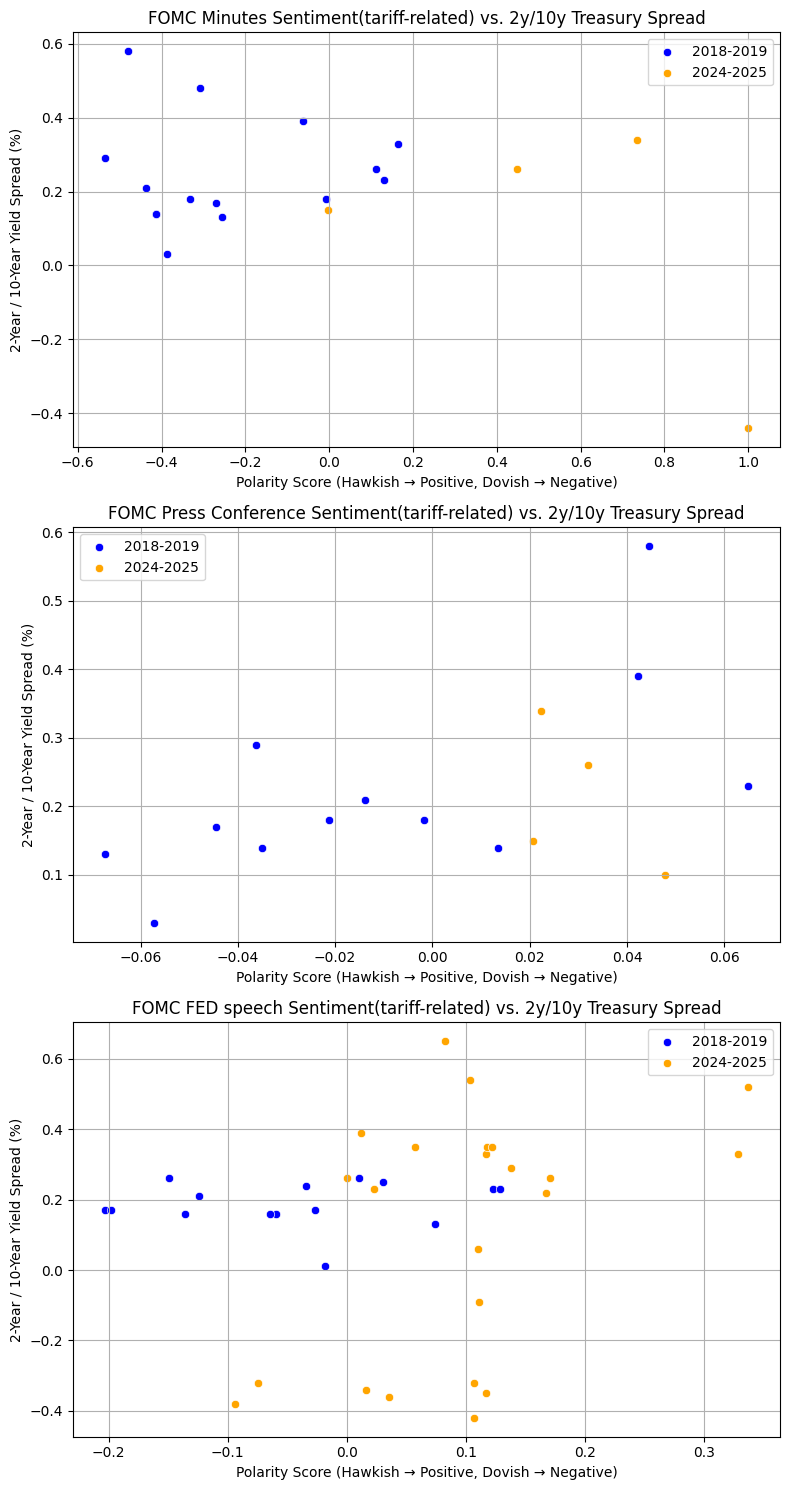

In [192]:
# See the correlation of polarity score and the spread
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 15))

# Plot each figure on a different axis
sns.scatterplot(data=df_1819_tariff, x='Tariff Polarity Score', y='2Y_10Y_Spread',label='2018-2019', color='blue', ax=axes[0])
sns.scatterplot(data=df_2425_tariff, x='Tariff Polarity Score', y='2Y_10Y_Spread',label='2024-2025', color='orange', ax=axes[0])
axes[0].set_title('FOMC Minutes Sentiment(tariff-related) vs. 2y/10y Treasury Spread')
axes[0].grid(True)
axes[0].set_xlabel('Polarity Score (Hawkish → Positive, Dovish → Negative)')
axes[0].set_ylabel('2-Year / 10-Year Yield Spread (%)')

sns.scatterplot(data=df_1819_2_tariff, x='Polarity Score', y='2Y_10Y_Spread',label='2018-2019', color='blue', ax=axes[1])
sns.scatterplot(data=df_2425_2_tariff, x='Polarity Score', y='2Y_10Y_Spread',label='2024-2025', color='orange', ax=axes[1])
axes[1].set_title('FOMC Press Conference Sentiment(tariff-related) vs. 2y/10y Treasury Spread')
axes[1].grid(True)
axes[1].set_xlabel('Polarity Score (Hawkish → Positive, Dovish → Negative)')
axes[1].set_ylabel('2-Year / 10-Year Yield Spread (%)')

sns.scatterplot(data=df_1819_3_tariff, x='Polarity Score', y='2Y_10Y_Spread',label='2018-2019', color='blue', ax=axes[2])
sns.scatterplot(data=df_2425_3_tariff, x='Polarity Score', y='2Y_10Y_Spread',label='2024-2025', color='orange', ax=axes[2])
axes[2].set_title('FOMC FED speech Sentiment(tariff-related) vs. 2y/10y Treasury Spread')
axes[2].grid(True)
axes[2].set_xlabel('Polarity Score (Hawkish → Positive, Dovish → Negative)')
axes[2].set_ylabel('2-Year / 10-Year Yield Spread (%)')

# Final adjustments
# for ax in axes:
#    ax.tick_params(axis='x', rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

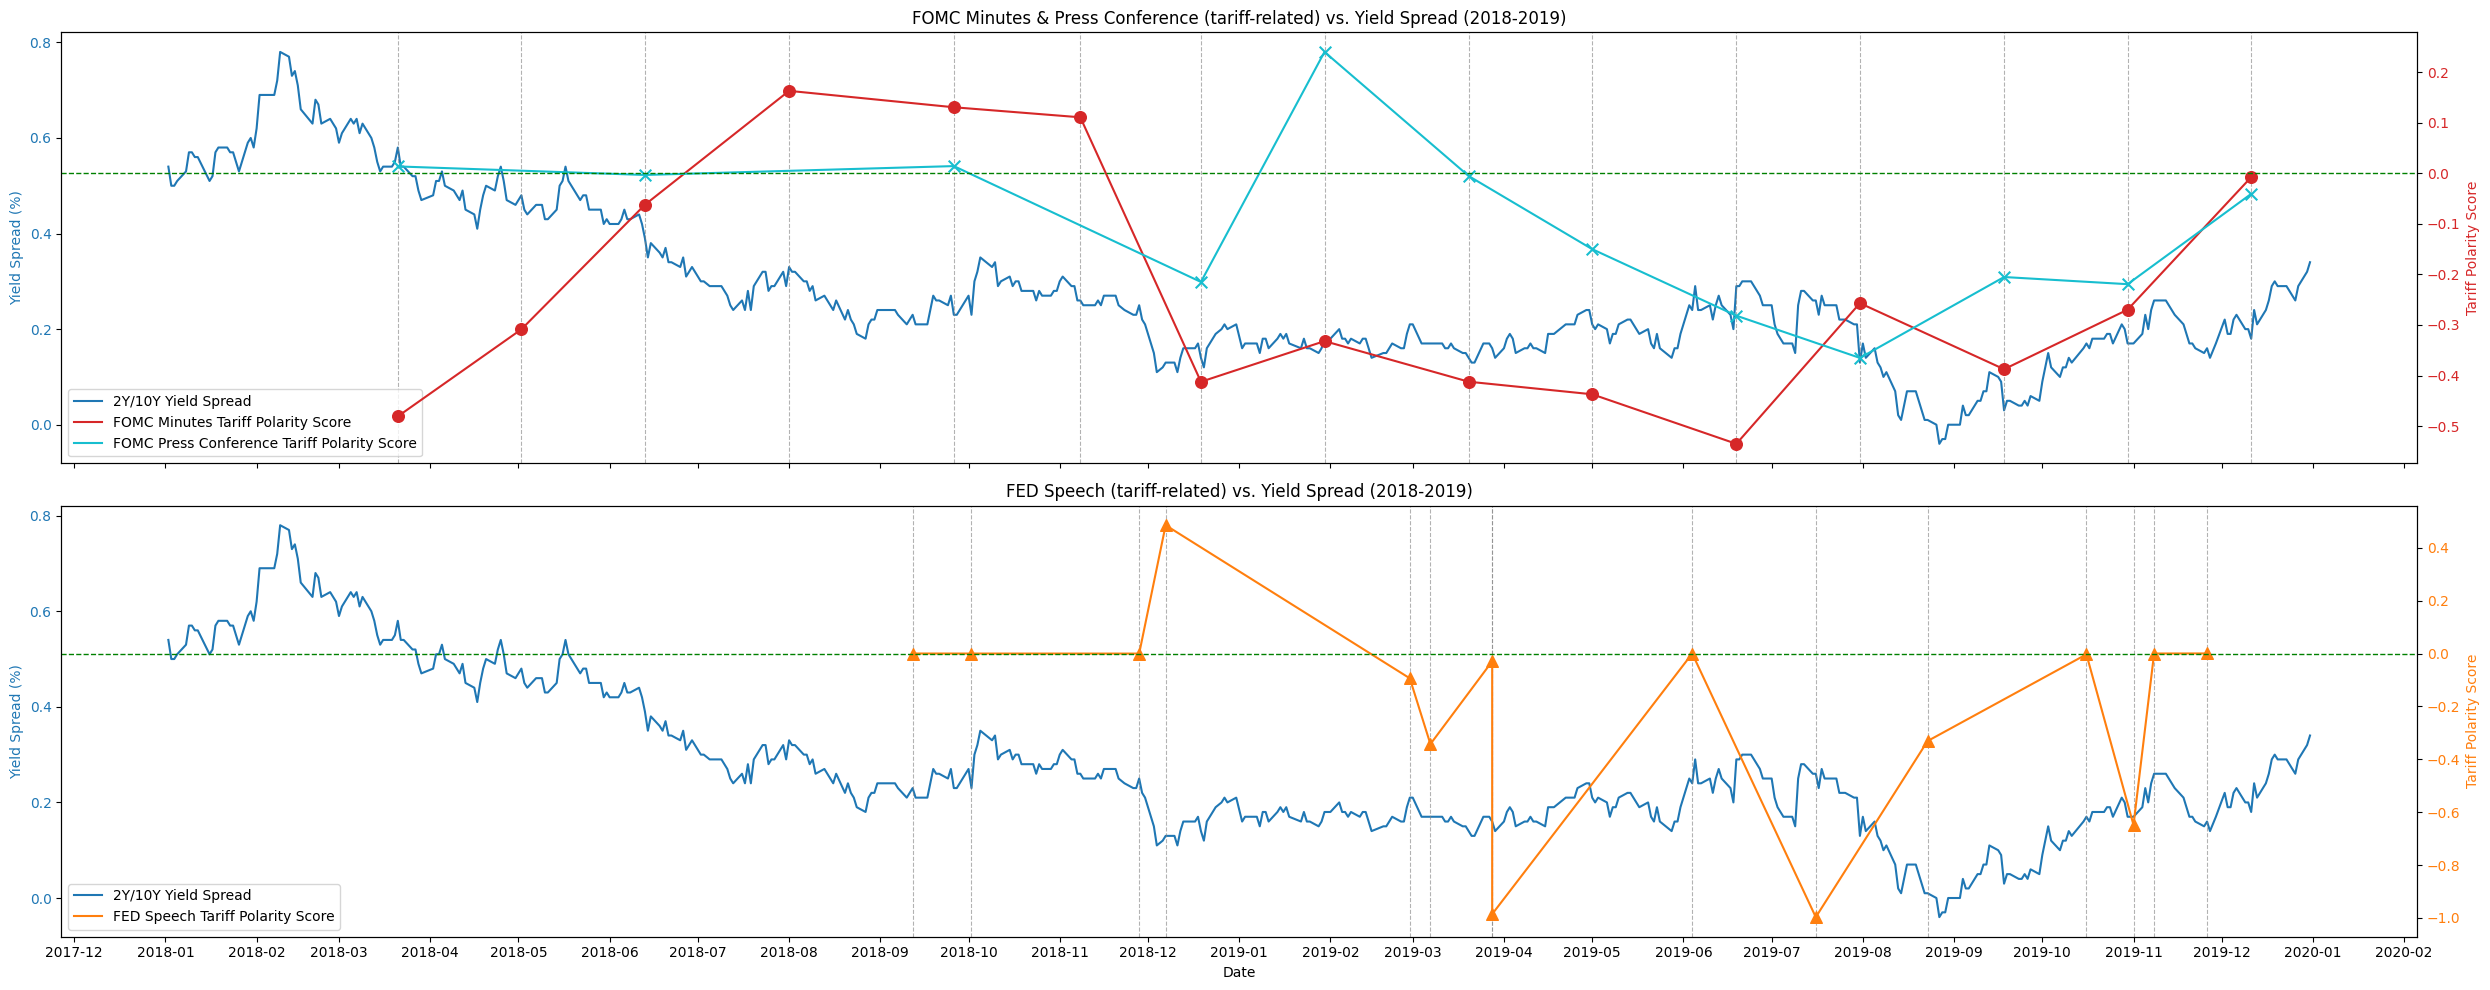

In [193]:
# 2018-2019: To compare how the spread change over the time with the polarity score (with a focus on tariff)

# Create two subplots sharing the same x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(25, 10), sharex=True)

# First subplot: Minutes + PC polarity + spread ======
ln1a = ax1.plot(spread_1819_df['Date'], spread_1819_df['2Y_10Y_Spread'], label='2Y/10Y Yield Spread', color='tab:blue')
ax1.set_ylabel('Yield Spread (%)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax1b = ax1.twinx()
ln2 = ax1b.plot(df_1819_tariff['Date'], df_1819_tariff['Tariff Polarity Score'], label='FOMC Minutes Tariff Polarity Score', color='tab:red')
ln3 = ax1b.plot(df_1819_2_tariff['Date'], df_1819_2_tariff['Tariff Polarity Score'], label='FOMC Press Conference Tariff Polarity Score', color='tab:cyan')
ax1b.scatter(df_1819_tariff['Date'], df_1819_tariff['Tariff Polarity Score'], color='tab:red', marker='o', s=70)
ax1b.scatter(df_1819_2_tariff['Date'], df_1819_2_tariff['Tariff Polarity Score'], color='tab:cyan', marker='x', s=70)
ax1b.set_ylabel('Tariff Polarity Score', color='tab:red')
ax1b.tick_params(axis='y', labelcolor='tab:red')
ax1b.axhline(y=0, color='green', linestyle='--', linewidth=1)

for sentiment_date in df_1819_tariff['Date']:
    ax1.axvline(sentiment_date, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

# Second subplot: FED Speech polarity + spread ======
ln1b = ax2.plot(spread_1819_df['Date'], spread_1819_df['2Y_10Y_Spread'], label='2Y/10Y Yield Spread', color='tab:blue')
ax2.set_ylabel('Yield Spread (%)', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

ax2b = ax2.twinx()
ln4 = ax2b.plot(df_1819_3_tariff['Date'], df_1819_3_tariff['Tariff Polarity Score'], label='FED Speech Tariff Polarity Score', color='tab:orange')
ax2b.scatter(df_1819_3_tariff['Date'], df_1819_3_tariff['Tariff Polarity Score'], color='tab:orange', marker='^', s=70)
ax2b.set_ylabel('Tariff Polarity Score', color='tab:orange')
ax2b.tick_params(axis='y', labelcolor='tab:orange')
ax2b.axhline(y=0, color='green', linestyle='--', linewidth=1)
for sentiment_date in df_1819_3_tariff['Date']:
    ax2.axvline(sentiment_date, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

# X-axis formatting
ax2.set_xlabel('Date')
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

lines_a = ln1a + ln2 + ln3
lines_b = ln1b + ln4
labels_a = [l.get_label() for l in lines_a]
labels_b = [l.get_label() for l in lines_b]

ax1.legend(lines_a, labels_a, loc='lower left')
ax2.legend(lines_b, labels_b, loc='lower left')

# Titles and layout
ax1.set_title('FOMC Minutes & Press Conference (tariff-related) vs. Yield Spread (2018-2019)')
ax2.set_title('FED Speech (tariff-related) vs. Yield Spread (2018-2019)')
plt.tight_layout()
plt.show()

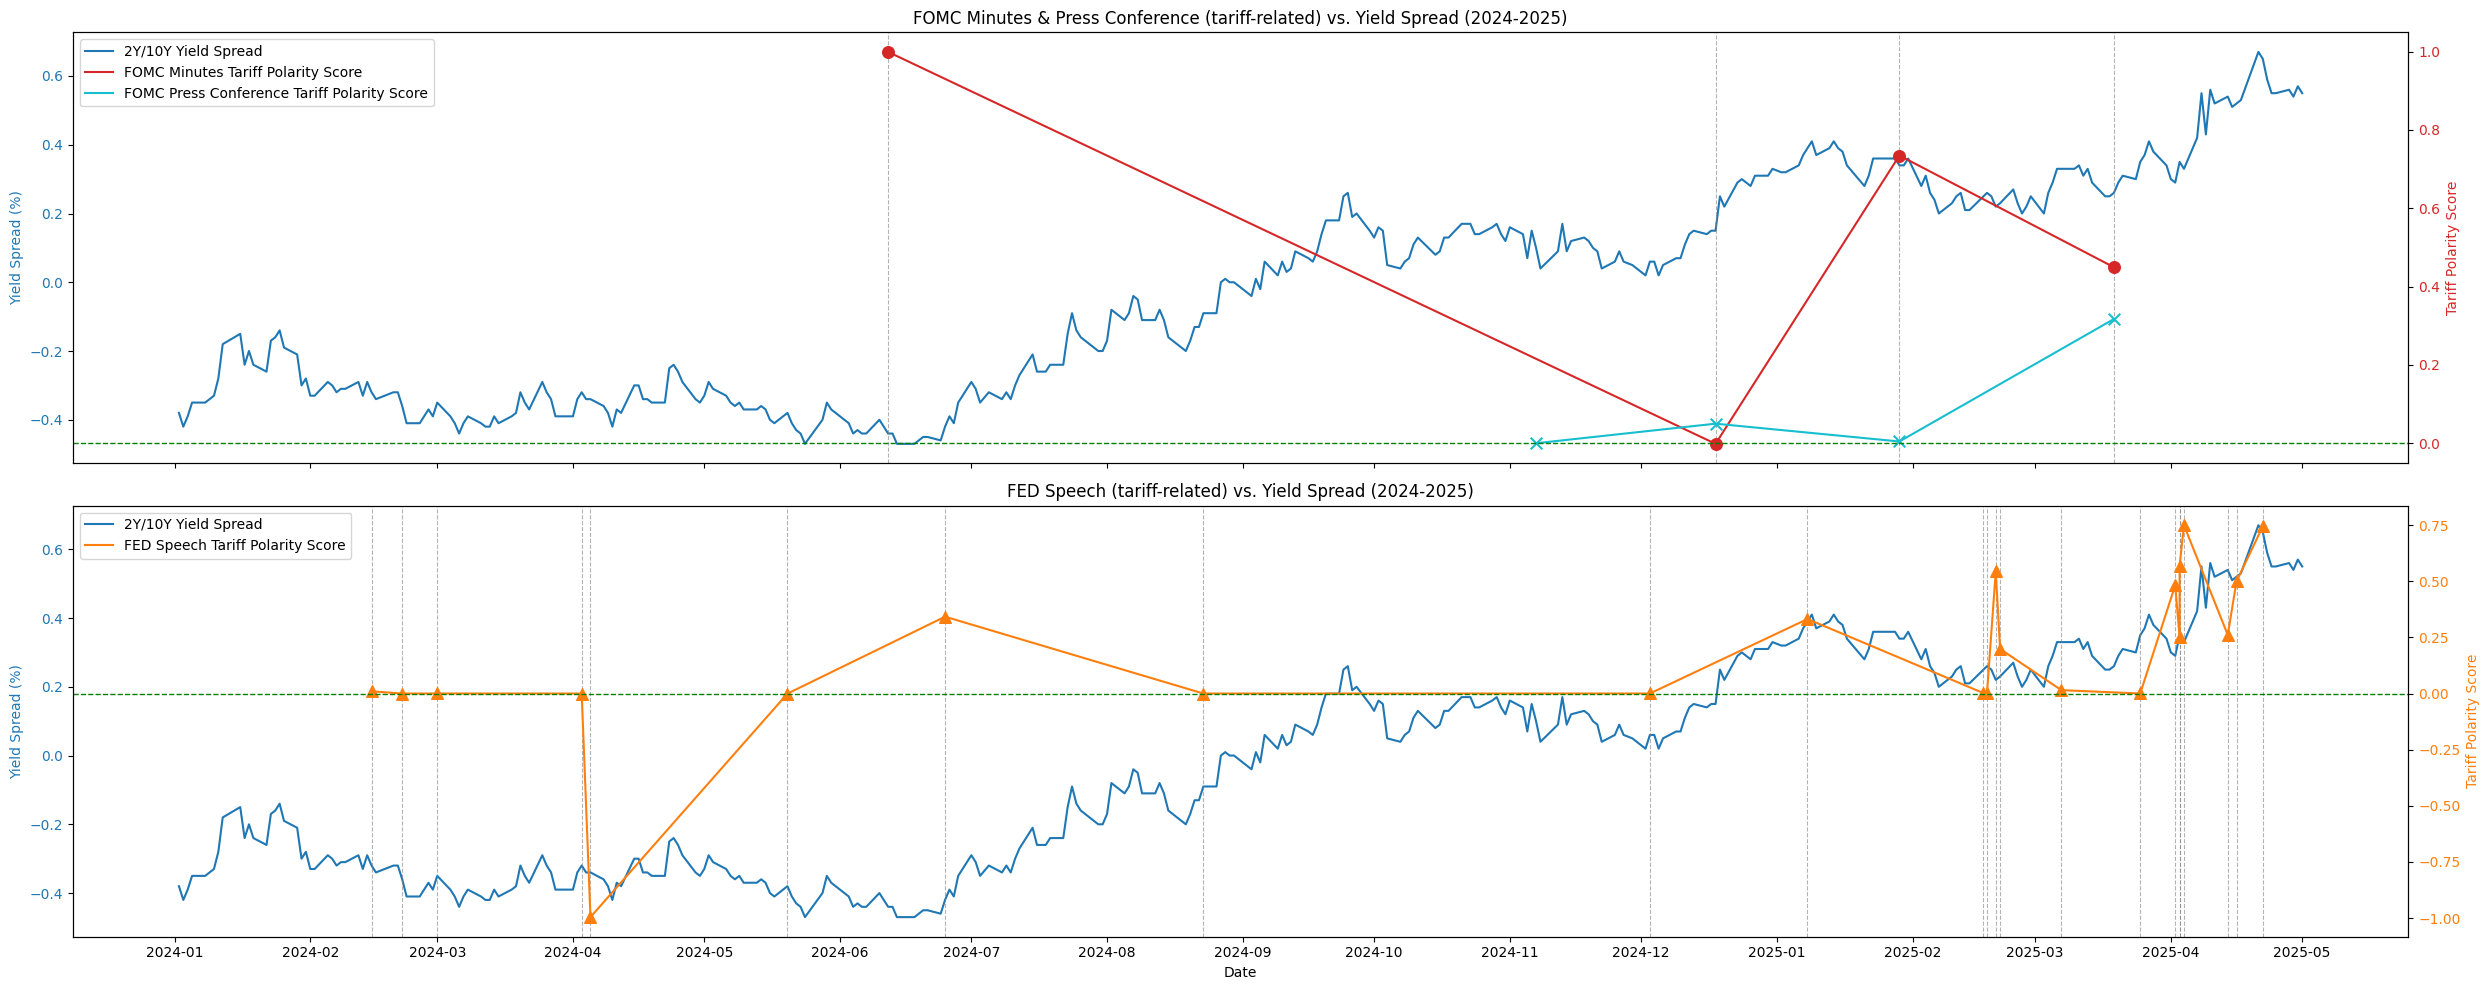

In [194]:
# 2024-2025: To compare how the spread change over the time with the polarity score (with a focus on tariff)

# Create two subplots sharing the same x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(25, 10), sharex=True)

# First subplot: Minutes + PC polarity + spread ======
ln1a = ax1.plot(spread_2425_df['Date'], spread_2425_df['2Y_10Y_Spread'], label='2Y/10Y Yield Spread', color='tab:blue')
ax1.set_ylabel('Yield Spread (%)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax1b = ax1.twinx()
ln2 = ax1b.plot(df_2425_tariff['Date'], df_2425_tariff['Tariff Polarity Score'], label='FOMC Minutes Tariff Polarity Score', color='tab:red')
ln3 = ax1b.plot(df_2425_2_tariff['Date'], df_2425_2_tariff['Tariff Polarity Score'], label='FOMC Press Conference Tariff Polarity Score', color='tab:cyan')
ax1b.scatter(df_2425_tariff['Date'], df_2425_tariff['Tariff Polarity Score'], color='tab:red', marker='o', s=70)
ax1b.scatter(df_2425_2_tariff['Date'], df_2425_2_tariff['Tariff Polarity Score'], color='tab:cyan', marker='x', s=70)
ax1b.set_ylabel('Tariff Polarity Score', color='tab:red')
ax1b.tick_params(axis='y', labelcolor='tab:red')
ax1b.axhline(y=0, color='green', linestyle='--', linewidth=1)

for sentiment_date in df_2425_tariff['Date']:
    ax1.axvline(sentiment_date, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

# Second subplot: FED Speech polarity + spread ======
ln1b = ax2.plot(spread_2425_df['Date'], spread_2425_df['2Y_10Y_Spread'], label='2Y/10Y Yield Spread', color='tab:blue')
ax2.set_ylabel('Yield Spread (%)', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

ax2b = ax2.twinx()
ln4 = ax2b.plot(df_2425_3_tariff['Date'], df_2425_3_tariff['Tariff Polarity Score'], label='FED Speech Tariff Polarity Score', color='tab:orange')
ax2b.scatter(df_2425_3_tariff['Date'], df_2425_3_tariff['Tariff Polarity Score'], color='tab:orange', marker='^', s=70)
ax2b.set_ylabel('Tariff Polarity Score', color='tab:orange')
ax2b.tick_params(axis='y', labelcolor='tab:orange')
ax2b.axhline(y=0, color='green', linestyle='--', linewidth=1)
for sentiment_date in df_2425_3_tariff['Date']:
    ax2.axvline(sentiment_date, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

# X-axis formatting
ax2.set_xlabel('Date')
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

lines_a = ln1a + ln2 + ln3
lines_b = ln1b + ln4
labels_a = [l.get_label() for l in lines_a]
labels_b = [l.get_label() for l in lines_b]

ax1.legend(lines_a, labels_a, loc='upper left')
ax2.legend(lines_b, labels_b, loc='upper left')

# Titles and layout
ax1.set_title('FOMC Minutes & Press Conference (tariff-related) vs. Yield Spread (2024-2025)')
ax2.set_title('FED Speech (tariff-related) vs. Yield Spread (2024-2025)')
plt.tight_layout()
plt.show()

In [195]:
df_1819_tariff = df_1819_tariff.reset_index(drop=True)
df_1819_2_tariff = df_1819_2_tariff.reset_index(drop=True)
df_1819_3_tariff = df_1819_3_tariff.reset_index(drop=True)

df_2425_tariff = df_2425_tariff.reset_index(drop=True)
df_2425_2_tariff = df_2425_2_tariff.reset_index(drop=True)
df_2425_3_tariff = df_2425_3_tariff.reset_index(drop=True)
df_2425_tariff.head()

,Unnamed: 0,Date,DGS10,DGS2,2Y_10Y_Spread,Filename,Total Segments,Hawkish %,Dovish %,Neutral %,Polarity Score,Tariff Mentions,Tariff % of Doc,Tariff Polarity Score
0,116,2024-06-12,4.31,4.75,-0.44,minute,216,58.796296,41.203704,19.582422,0.052976,1,0.462963,0.999012
1,251,2024-12-18,4.50,4.35,0.15,minute,212,54.716981,45.283019,20.345346,0.014539,4,1.886792,-0.001701
2,281,2025-01-29,4.55,4.21,0.34,minute,243,66.255144,33.744856,9.926845,0.166972,4,1.646091,0.734495
3,316,2025-03-19,4.25,3.99,0.26,minute,227,57.709251,42.290749,16.588650,0.110327,19,8.370044,0.449260


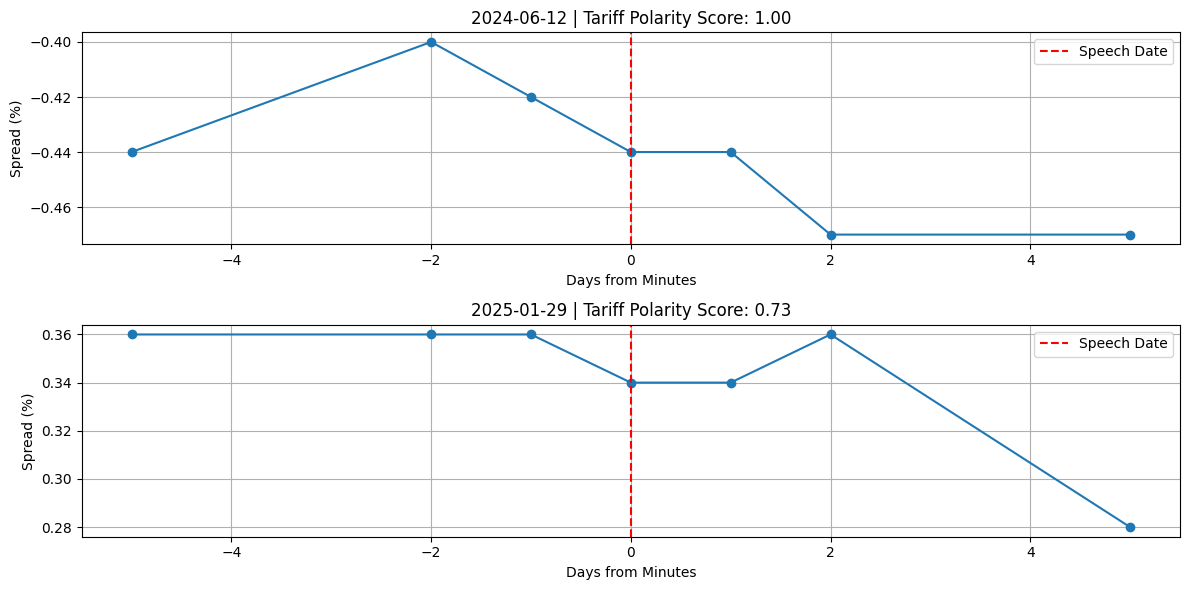

In [203]:
# Set the number of days before and after
window = 5
# Only plot for dates with obvious sentiments
df_2425_tariff_o = df_2425_tariff[abs(df_2425_tariff['Tariff Polarity Score']) > 0.5 ]
df_2425_2_tariff_o = df_2425_2_tariff[abs(df_2425_2_tariff['Tariff Polarity Score']) > 0.1 ]
df_2425_3_tariff_o = df_2425_3_tariff[abs(df_2425_3_tariff['Tariff Polarity Score']) > 0.1 ]
df_2425_tariff_o = df_2425_tariff_o.reset_index(drop=True)
df_2425_2_tariff_o = df_2425_2_tariff_o.reset_index(drop=True)
df_2425_3_tariff_o = df_2425_3_tariff_o.reset_index(drop=True)

# Start plotting
fig, axes = plt.subplots(len(df_2425_tariff_o), 1, figsize=(12, len(df_2425_tariff_o) * 3), sharey=False)

for i, row in df_2425_tariff_o.iterrows():
    # print(i)
    date = row['Date']
    score = row['Tariff Polarity Score']
    
    # Slice spread data ± window
    mask = (spread_2425_df['Date'] >= date - pd.Timedelta(days=window)) & (spread_2425_df['Date'] <= date + pd.Timedelta(days=window))
    local_df = spread_2425_df[mask].copy()
    
    # Normalize x-axis to relative days
    local_df['Days from Speech'] = (local_df['Date'] - date).dt.days

    # Plot
    ax = axes[i] if len(df_2425_tariff_o) > 1 else axes
    ax.plot(local_df['Days from Speech'], local_df['2Y_10Y_Spread'], marker='o')
    ax.axvline(0, color='red', linestyle='--', label='Speech Date')
    ax.set_title(f"{date.strftime('%Y-%m-%d')} | Tariff Polarity Score: {score:.2f}")
    ax.grid(True)
    ax.set_xlabel("Days from Minutes")
    ax.set_ylabel("Spread (%)")
    ax.legend()

plt.tight_layout()
plt.show()

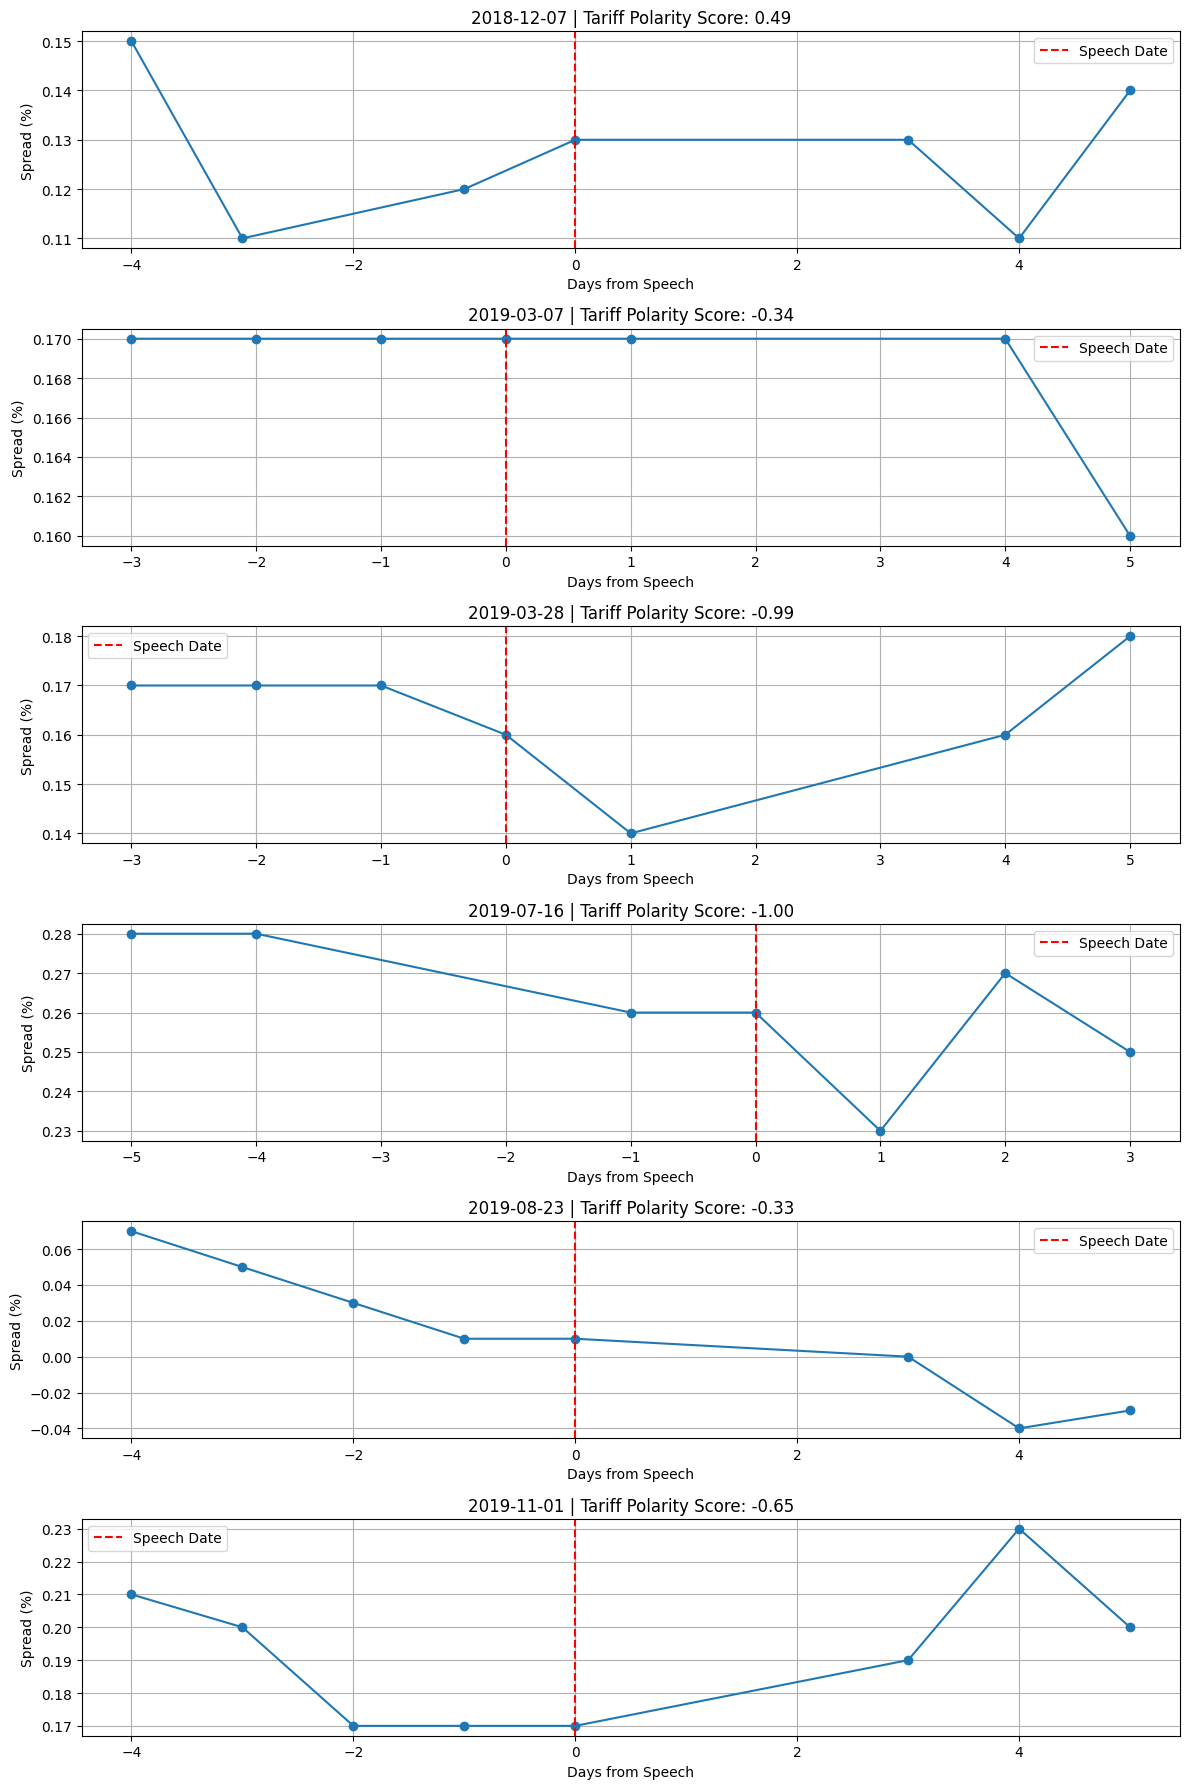

In [197]:
# Set the number of days before and after
window = 5
# Only plot for dates with obvious sentiments
df_1819_tariff_o = df_1819_tariff[abs(df_1819_tariff['Tariff Polarity Score']) > 0.1 ]
df_1819_2_tariff_o = df_1819_2_tariff[abs(df_1819_2_tariff['Tariff Polarity Score']) > 0.1 ]
df_1819_3_tariff_o = df_1819_3_tariff[abs(df_1819_3_tariff['Tariff Polarity Score']) > 0.1 ]
df_1819_tariff_o = df_1819_tariff_o.reset_index(drop=True)
df_1819_2_tariff_o = df_1819_2_tariff_o.reset_index(drop=True)
df_1819_3_tariff_o = df_1819_3_tariff_o.reset_index(drop=True)

# Start plotting
fig, axes = plt.subplots(len(df_1819_3_tariff_o), 1, figsize=(12, len(df_1819_3_tariff_o) * 3), sharey=False)

for i, row in df_1819_3_tariff_o.iterrows():
    # print(i)
    date = row['Date']
    score = row['Tariff Polarity Score']
    
    # Slice spread data ± window
    mask = (spread_1819_df['Date'] >= date - pd.Timedelta(days=window)) & (spread_1819_df['Date'] <= date + pd.Timedelta(days=window))
    local_df = spread_1819_df[mask].copy()
    
    # Normalize x-axis to relative days
    local_df['Days from Speech'] = (local_df['Date'] - date).dt.days

    # Plot
    ax = axes[i] if len(df_1819_3_tariff_o) > 1 else axes
    ax.plot(local_df['Days from Speech'], local_df['2Y_10Y_Spread'], marker='o')
    ax.axvline(0, color='red', linestyle='--', label='Speech Date')
    ax.set_title(f"{date.strftime('%Y-%m-%d')} | Tariff Polarity Score: {score:.2f}")
    ax.grid(True)
    ax.set_xlabel("Days from Speech")
    ax.set_ylabel("Spread (%)")
    ax.legend()

plt.tight_layout()
plt.show()